In [118]:
import os
import pandas as pd
from features import *
import matplotlib.pyplot as plt

In [119]:
def complete_dict(list_dataframe, clean):
    if clean:
        path = "../Data/train/with_label/clean"
    else:
        path = "../Data/train/with_label/dirty"
    for e in os.scandir(path):
        if e.is_file():
            dict = {}
            path = e.path
            dict['name'] = e.name
            features_img = extract_features(path)
            for key in features_img.keys():
                dict[key] = features_img[key]
            if clean:
                dict['class'] = 'clean'
            else:
                dict['class'] = 'dirty'
            list_dataframe.append(dict)

In [120]:
def get_dataframe() -> list:
    list_dataframe = []

    complete_dict(list_dataframe, 1)
    complete_dict(list_dataframe, 0)

    return list_dataframe

In [121]:
list_df = get_dataframe()
df = pd.DataFrame(list_df)


In [122]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,hist_rgb,hist_luminance,edge_density,class
0,train_clean_img_001.jpeg,69.07,600,600,122.39,127.30,121.97,125.22429,255,29.08,"{""red"": [110, 28, 27, 20, 38, 36, 58, 58, 73, ...","[1, 33, 27, 15, 22, 21, 28, 35, 37, 45, 41, 61...",0.1123,clean
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,35.08,"{""red"": [8, 3, 1, 5, 2, 7, 12, 31, 34, 36, 61,...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,clean
2,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,44.79,"{""red"": [52, 27, 31, 31, 43, 41, 58, 51, 60, 5...","[3, 13, 10, 18, 36, 33, 41, 48, 59, 75, 61, 67...",0.0541,clean
3,train_clean_img_004.jpeg,47.19,600,600,130.69,132.25,129.66,131.48830,254,17.20,"{""red"": [8, 1, 3, 7, 12, 6, 14, 12, 23, 23, 25...","[0, 4, 2, 4, 2, 3, 9, 13, 15, 20, 22, 30, 41, ...",0.0677,clean
4,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.31,109.33037,255,40.16,"{""red"": [65, 40, 38, 86, 154, 289, 469, 834, 1...","[11, 44, 69, 108, 240, 408, 844, 1573, 2059, 2...",0.0330,clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,train_no_label_img_539.jpeg,517.28,1918,814,92.01,93.92,92.50,93.18703,253,56.45,"{""red"": [2, 6, 3, 14, 14, 28, 35, 55, 76, 127,...","[0, 0, 1, 1, 3, 0, 3, 8, 25, 24, 51, 69, 85, 1...",0.0674,dirty
138,train_no_label_img_541.jpeg,79.12,600,450,86.47,82.63,76.20,83.04514,250,51.02,"{""red"": [0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 8, 9, 2...","[0, 0, 0, 0, 0, 1, 1, 3, 1, 2, 7, 13, 25, 44, ...",0.1270,dirty
139,train_no_label_img_545.jpeg,36.78,600,450,121.41,114.85,106.24,115.82990,254,41.45,"{""red"": [5, 2, 0, 1, 2, 6, 3, 2, 8, 3, 6, 12, ...","[0, 4, 1, 1, 5, 8, 3, 8, 9, 18, 12, 18, 19, 18...",0.1321,dirty
140,train_no_label_img_546.jpeg,25.79,600,337,166.24,164.47,160.61,164.55919,245,22.30,"{""red"": [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 1, ...",0.0479,dirty


In [123]:
df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density']] = df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density']].astype(float)

df[['image_width', 'image_height', 'contraste']] = df[['image_width', 'image_height', 'contraste']].astype(int)

In [124]:
df[df['class'] == 'clean'].describe()

,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,edge_density
count,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,81.238816,652.828947,658.723684,115.571711,114.641316,108.773553,114.250579,251.368421,47.721974,0.079533
std,204.012221,399.527801,329.990287,17.949297,17.443162,19.654591,17.517082,9.021223,21.172992,0.034333
min,16.980000,500.000000,323.000000,61.390000,48.540000,31.350000,50.422490,197.000000,10.430000,0.014900
25%,39.392500,600.000000,517.500000,104.822500,106.237500,97.245000,105.692022,253.000000,35.575000,0.054325
50%,56.580000,600.000000,600.000000,115.610000,115.840000,110.145000,115.294080,255.000000,45.120000,0.072550
75%,69.312500,600.000000,715.000000,127.785000,125.092500,119.652500,125.021885,255.000000,56.187500,0.103450
max,1821.850000,4000.000000,3000.000000,156.360000,153.290000,155.560000,152.468600,255.000000,154.920000,0.167000


In [125]:
df[df['class'] == 'dirty'].describe()


,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,edge_density
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,398.206212,877.651515,804.348485,114.951364,112.068333,105.564394,112.188910,251.181818,50.593636,0.079938
std,1005.359270,790.960536,757.736599,17.831268,19.793513,22.948041,18.936141,7.011878,26.130414,0.038177
min,9.380000,187.000000,141.000000,66.520000,58.600000,39.770000,65.589210,223.000000,20.280000,0.016000
25%,31.097500,600.000000,375.000000,105.157500,102.145000,93.597500,101.574815,250.250000,35.500000,0.047925
50%,57.000000,600.000000,546.000000,114.780000,114.575000,108.690000,114.686045,254.000000,44.700000,0.082500
75%,105.902500,600.000000,800.000000,126.142500,124.120000,119.245000,124.658295,255.000000,55.727500,0.106975
max,6458.140000,4032.000000,3264.000000,166.240000,164.470000,160.610000,164.559190,255.000000,155.390000,0.148800


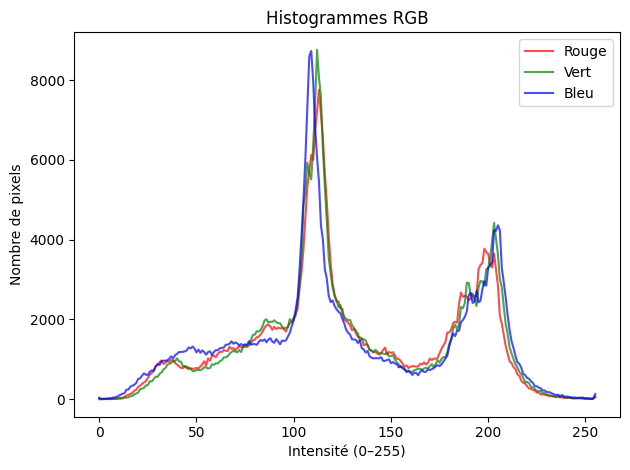

In [126]:
hist_string = df[df['class'] == "dirty"].head(1)["hist_rgb"]
hist = json.loads(hist_string.values[0])

plt.plot(hist["red"],   label="Rouge", color="red",   alpha=0.7)
plt.plot(hist["green"], label="Vert",  color="green", alpha=0.7)
plt.plot(hist["blue"],  label="Bleu",  color="blue",  alpha=0.7)


plt.xlabel("Intensité (0–255)")
plt.ylabel("Nombre de pixels")
plt.title("Histogrammes RGB")
plt.legend()
plt.tight_layout()
plt.show()

plt.show()

In [127]:
df_clean = df[df['class'] == 'clean']
df_dirty = df[df['class'] == 'dirty']

In [128]:
df_dirty = df_dirty.reset_index()

Plot width for each images

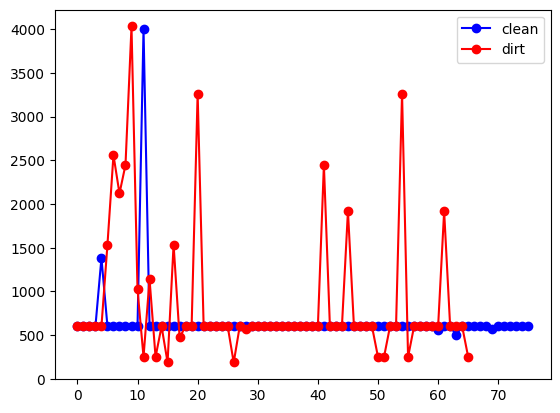

In [129]:
plt.plot(df_clean.index, df_clean['image_width'], '-o', c='blue', label="clean")
plt.plot(df_dirty.index, df_dirty['image_width'], '-o', c='red', label="dirt")
plt.legend()
plt.show()

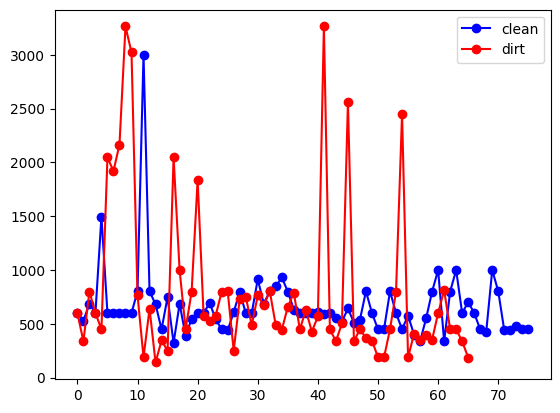

In [130]:
plt.plot(df_clean.index, df_clean['image_height'], '-o', c='blue', label="clean")
plt.plot(df_dirty.index, df_dirty['image_height'], '-o', c='red', label="dirt")
plt.legend()
plt.show()

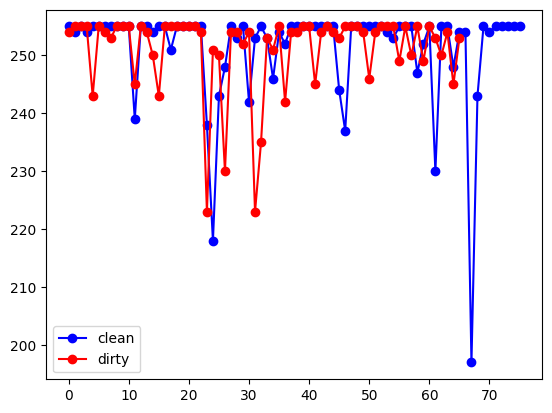

251.3684210526316 251.1818181818182


In [135]:
plt.plot(df_clean.index, df_clean['contraste'], '-o', c='blue', label="clean")
plt.plot(df_dirty.index, df_dirty['contraste'], '-o', c='red', label="dirty")
plt.legend()
plt.show()

print(df_clean['contraste'].mean(), df_dirty['contraste'].mean())

Dans ton coinggg

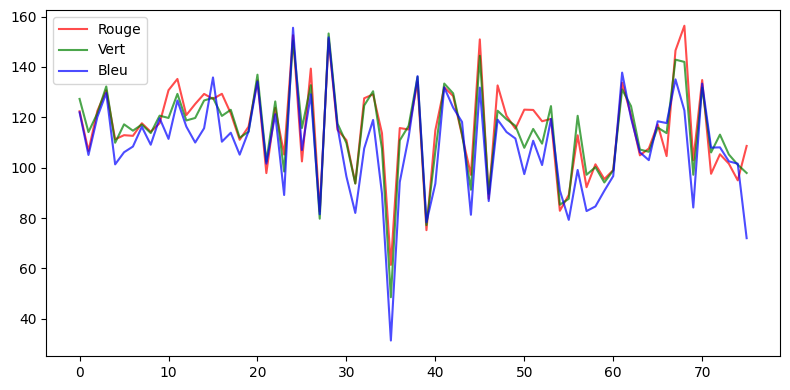

In [132]:

r_values = df_clean["mean_r"]
g_values = df_clean["mean_g"]
b_values = df_clean["mean_b"]
plt.figure(figsize=(8, 4))
plt.plot(r_values,   label="Rouge", color="red",   alpha=0.7)
plt.plot(g_values, label="Vert",  color="green", alpha=0.7)
plt.plot(b_values,  label="Bleu",  color="blue",  alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

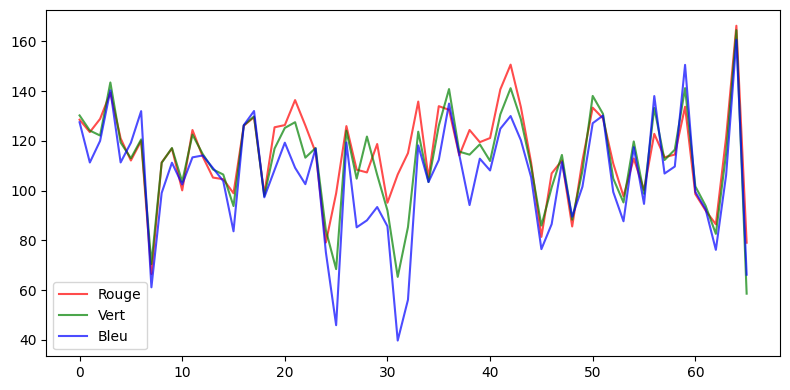

In [133]:
r_values = df_dirty["mean_r"]
g_values = df_dirty["mean_g"]
b_values = df_dirty["mean_b"]
plt.figure(figsize=(8, 4))
plt.plot(r_values,   label="Rouge", color="red",   alpha=0.7)
plt.plot(g_values, label="Vert",  color="green", alpha=0.7)
plt.plot(b_values,  label="Bleu",  color="blue",  alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [134]:
diff_clean = abs(df_clean['mean_r'] - df_clean['mean_g']) + abs(df_clean['mean_r'] - df_clean['mean_b']) + abs(df_clean['mean_g'] - df_clean['mean_b'])
diff_dirty = abs(df_dirty['mean_r'] - df_dirty['mean_g']) + abs(df_dirty['mean_r'] - df_dirty['mean_b']) + abs(df_dirty['mean_g'] - df_dirty['mean_b'])

# plt.plot(df_clean.index, diff_clean, '-o', c='blue', label="clean")
# plt.plot(df_dirty.index, diff_dirty, '-o', c='red', label="dirty")
# plt.legend()
# plt.show()
print(diff_clean.mean())
print(diff_dirty.mean())

20.295263157894734
25.463939393939395


In [141]:
full_dirty = df[df['name'] == "train_no_label_img_521.jpeg"]
full_dirty

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,hist_rgb,hist_luminance,edge_density,class
125,train_no_label_img_521.jpeg,31.21,600,345,112.12,107.95,101.57,108.46951,254,42.62,"{""red"": [26, 42, 62, 116, 144, 268, 365, 500, ...","[12, 32, 43, 90, 138, 248, 378, 495, 634, 713,...",0.044,dirty


In [142]:
cleanest = df[df['name'] == "train_clean_img_002.jpeg"]
cleanest

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,hist_rgb,hist_luminance,edge_density,class
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,35.08,"{""red"": [8, 3, 1, 5, 2, 7, 12, 31, 34, 36, 61,...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,clean


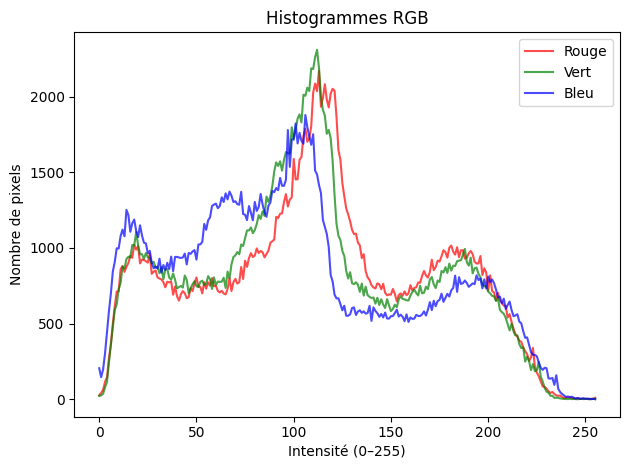

In [143]:
hist_string = full_dirty["hist_rgb"]
hist = json.loads(hist_string.values[0])


plt.plot(hist["red"],   label="Rouge", color="red",   alpha=0.7)
plt.plot(hist["green"], label="Vert",  color="green", alpha=0.7)
plt.plot(hist["blue"],  label="Bleu",  color="blue",  alpha=0.7)


plt.xlabel("Intensité (0–255)")
plt.ylabel("Nombre de pixels")
plt.title("Histogrammes RGB")
plt.legend()
plt.tight_layout()
plt.show()

plt.show()

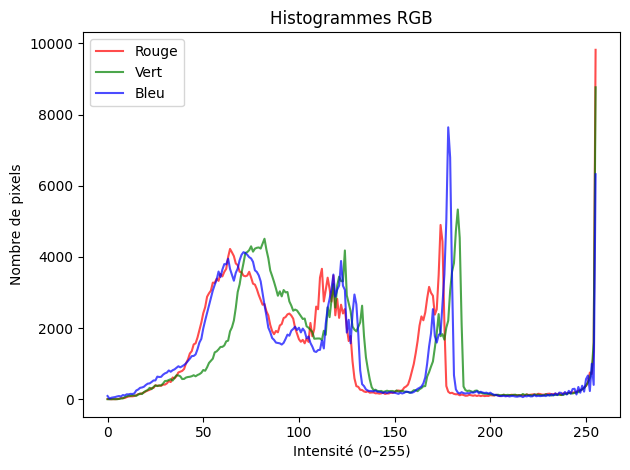

In [144]:
hist_string = cleanest["hist_rgb"]
hist = json.loads(hist_string.values[0])


plt.plot(hist["red"],   label="Rouge", color="red",   alpha=0.7)
plt.plot(hist["green"], label="Vert",  color="green", alpha=0.7)
plt.plot(hist["blue"],  label="Bleu",  color="blue",  alpha=0.7)


plt.xlabel("Intensité (0–255)")
plt.ylabel("Nombre de pixels")
plt.title("Histogrammes RGB")
plt.legend()
plt.tight_layout()
plt.show()

plt.show()